In [1]:
import sys
import os

project_root = os.path.abspath("../../")
if project_root not in sys.path:
    sys.path.append(project_root)

from src.preprocessors import ContextDataFeatureEngineering
import pandas as pd

In [2]:
context = pd.read_csv('../../data/Train-Test Splits/Context/train.csv')



In [3]:
context = ContextDataFeatureEngineering().fit_transform(context)
context_column_map = {
    "user_id": "user_id",
    "track_id": "track_id",
    "hashtag": "Hash tags",
    "created_at": "Timestamp of the activity",
    "score": "Calculated value for the post",
    "lang": "Primary language for the user profile",
    "tweet_lang": "Primary language for the specific post",
    "time_zone": "Regional setting for the user",
    "instrumentalness": "Probability that the track contains no vocals",
    "liveness": "Likelihood the recording was a live performance",
    "speechiness": "Presence of spoken words",
    "danceability": "Suitability for dancing based on tempo and beat",
    "valence": "Musical positiveness",
    "loudness": "Overall volume in decibels",
    "tempo": "Speed of the track in beats per minute",
    "acousticness": "Likelihood that the track is not electronic",
    "energy": "Perceived intensity and activity level",
    "mode": "Major or minor status of the track",
    "key": "Musical scale of the track",
    "rating": "User-assigned or system-generated preference score"
}

context = context.rename(columns=context_column_map)

In [4]:
context.head()

,user_id,track_id,Hash tags,Timestamp of the activity,Calculated value for the post,Primary language for the user profile,Primary language for the specific post,Regional setting for the user,Probability that the track contains no vocals,Likelihood the recording was a live performance,Presence of spoken words,Suitability for dancing based on tempo and beat,Musical positiveness,Overall volume in decibels,Speed of the track in beats per minute,Likelihood that the track is not electronic,Perceived intensity and activity level,Major or minor status of the track,Musical scale of the track,User-assigned or system-generated preference score
0,823214346,b129f3e0a0bdc1e61c57ce994f9d2932,kiss92,2014-01-01 05:59:38,0.8,English,English,UTC+08:00,0.000000,0.0764,0.0240,0.549,0.320,-7.698,80.133,0.341000,0.408,1.0,8.0,1
1,823214346,64b30f6ac1acecb7cef9dc890e1c3ea7,kiss92,2014-01-01 06:06:15,0.8,English,English,UTC+08:00,0.018300,0.1090,0.0407,0.585,0.380,-6.440,127.955,0.000357,0.759,1.0,9.0,1
2,823214346,cc1a46ee0446538ecf6b65db01c30cd8,kiss92,2014-01-01 06:11:07,0.8,English,English,UTC+08:00,0.000000,0.0931,0.0345,0.489,0.270,-4.197,92.526,0.077000,0.846,1.0,4.0,1
3,823214346,dbbd8525c1bc48cc791bfe618b74bac6,kiss92,2014-01-01 06:19:43,0.8,English,English,UTC+08:00,0.000000,0.0909,0.0314,0.607,0.576,-4.217,122.010,0.032700,0.934,1.0,3.0,1
4,823214346,dbdbb866939c1ab1dfd0d5cfac740eaa,kiss92,2014-01-01 06:23:47,0.8,English,English,UTC+08:00,0.000005,0.0951,0.1730,0.507,0.768,-5.581,99.252,0.081800,0.923,1.0,0.0,1


<Axes: title={'center': 'Activity distribution by post create time'}, xlabel='Timestamp of the activity'>

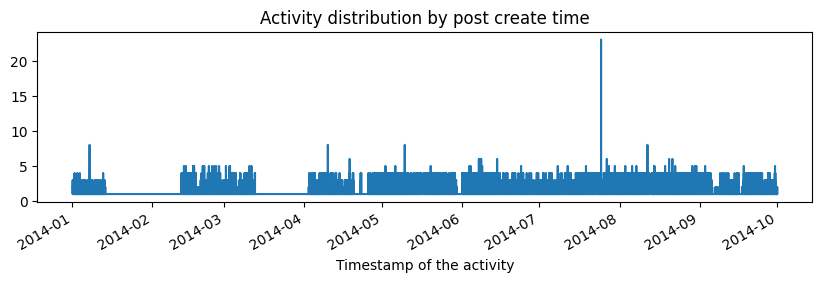

In [5]:
context.groupby('Timestamp of the activity').size().plot(figsize=(10,2.5), title="Activity distribution by post create time")

In [6]:
users = context.groupby('user_id').size()
users[users > 1].describe()

count     1830.000000
mean       139.267760
std       1557.725416
min          2.000000
25%          2.000000
50%          4.000000
75%         11.000000
max      41379.000000
dtype: float64

<Axes: title={'center': 'Calculated value for the post'}, ylabel='Frequency'>

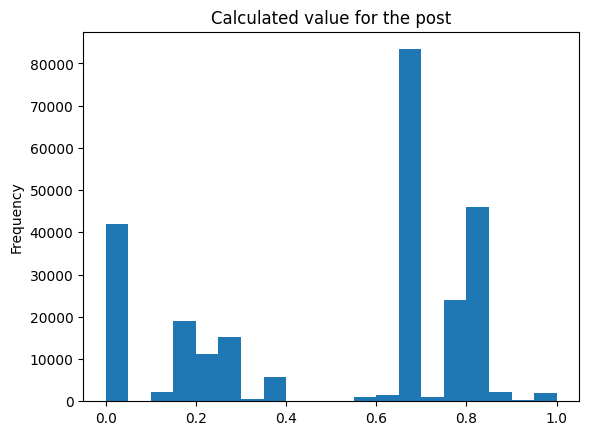

In [18]:
context['Calculated value for the post'].plot.hist(bins=20, title='Calculated value for the post')

<Axes: title={'center': 'Probability that the track contains no vocals'}, ylabel='Frequency'>

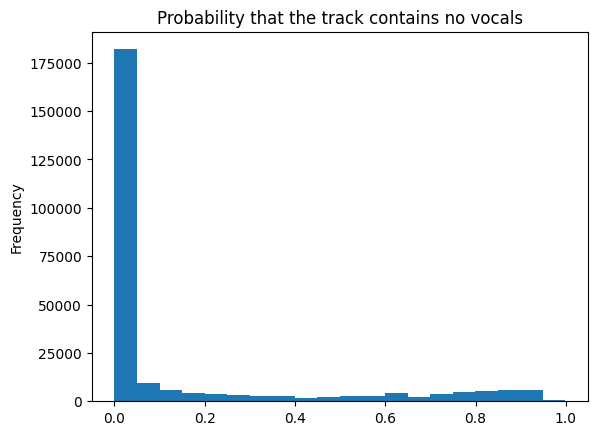

In [19]:
context['Probability that the track contains no vocals'].plot.hist(bins=20, title='Probability that the track contains no vocals')

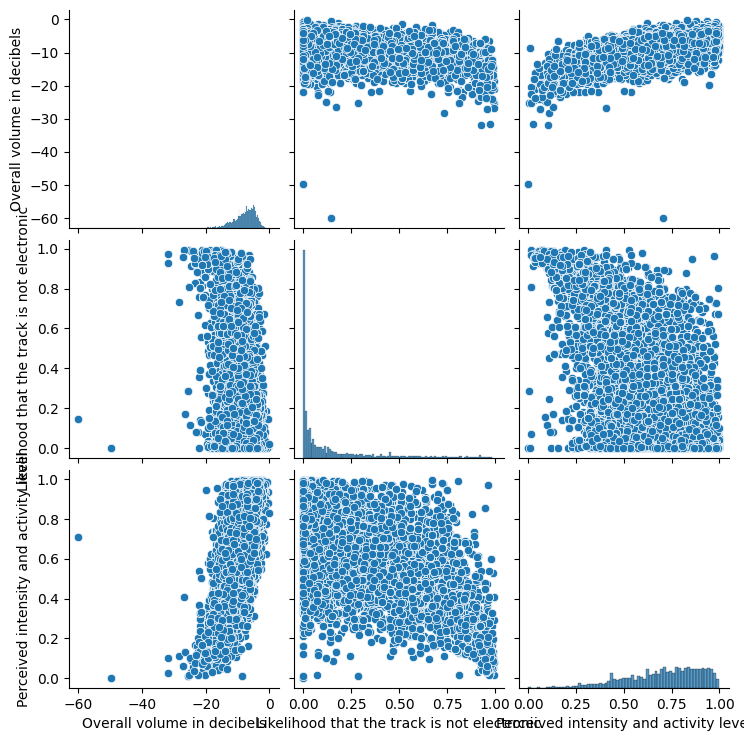

In [33]:
import seaborn as sb 
vars = [
    'Overall volume in decibels',
    'Likelihood that the track is not electronic',
    'Perceived intensity and activity level'
]
sb.pairplot(
    context.sample(n=50000), 
    x_vars=vars,
    y_vars=vars
)


In [7]:
context.nunique()

user_id                                                 3982
track_id                                               22092
Hash tags                                               3431
Timestamp of the activity                             215030
Calculated value for the post                            349
Primary language for the user profile                     28
Primary language for the specific post                    36
Regional setting for the user                             30
Probability that the track contains no vocals           4633
Likelihood the recording was a live performance         1592
Presence of spoken words                                1209
Suitability for dancing based on tempo and beat          903
Musical positiveness                                    1357
Overall volume in decibels                             10283
Speed of the track in beats per minute                 17836
Likelihood that the track is not electronic             4311
Perceived intensity and 

In [34]:
context.info()

<class 'pandas.DataFrame'>
RangeIndex: 257012 entries, 0 to 257011
Data columns (total 20 columns):
 #   Column                                              Non-Null Count   Dtype         
---  ------                                              --------------   -----         
 0   user_id                                             257012 non-null  int64         
 1   track_id                                            257012 non-null  str           
 2   Hash tags                                           257012 non-null  str           
 3   Timestamp of the activity                           257012 non-null  datetime64[us]
 4   Calculated value for the post                       257012 non-null  float64       
 5   Primary language for the user profile               257012 non-null  str           
 6   Primary language for the specific post              257012 non-null  str           
 7   Regional setting for the user                       257012 non-null  str           
 8   Proba